In [1]:
%pip install numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from micrograd.engine import Value

a = Value(-4.0, id='a')
b = Value(2.0, id='b')
c = a + b
d = a * b + b**3
c += c + Value(1.0, id="1")
c += Value(1.0, id="1") + c + (-a)
d += d * Value(2.0, id="2") + (b + a).relu()
d += Value(3.0, id="3") * d + (b - a).relu()
e = c - d
f = e**2
g = f * (Value(2.0, id="2")**-1)
g += Value(10.0, id="10") * (f**-1)
print(f'{g.data:.4f}') # prints 24.7041, the outcome of this forward pass
g.backward()
print(f'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da
print(f'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db

24.7041
a + b + a + b + 1 + 1 + a + b + a + b + 1 + a * -1 + a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + 3 * a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + relu b + a * -1 * -1 ** 2 * 2 ** -1 + 10 * a + b + a + b + 1 + 1 + a + b + a + b + 1 + a * -1 + a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + 3 * a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + relu b + a * -1 * -1 ** 2 ** -1
backward add from a + b + a + b + 1 + 1 + a + b + a + b + 1 + a * -1 + a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + 3 * a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + relu b + a * -1 * -1 ** 2 * 2 ** -1 + 10 * a + b + a + b + 1 + 1 + a + b + a + b + 1 + a * -1 + a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + 3 * a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + relu b + a * -1 * -1 ** 2 ** -1: a + b + a + b + 1 + 1 + a + b + a + b + 1 + a * -1 + a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + 3 * a * b + b ** 3 + a * b + b ** 3 * 2 + relu b + a + relu b + a * -1 * -1 ** 2 * 

###  MicroGrad demo

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

In [4]:
np.random.seed(1337)
random.seed(1337)

In [26]:
X = np.asarray([
    [ 1.12211461e+00,  8.14771734e-02],
    [-8.18829413e-01,  5.87900639e-02],
    [ 1.61370966e+00, -1.24645900e-01],
    [-9.23009184e-01,  3.65228899e-01],
    [ 1.43851462e-01,  4.43800492e-02],
    [ 1.64472466e-01,  1.17383457e-01],
    [ 1.33877062e+00, -2.38009933e-01],
    [ 8.71148615e-01, -4.22717587e-01],
    [ 1.83129946e+00, -1.41043828e-01],
    [ 4.87571202e-01,  6.39092830e-01],
    [ 3.74623511e-02,  4.23588090e-01],
    [-4.43916853e-01,  8.96739312e-01],
    [-8.12229494e-01,  9.12090924e-01],
    [ 1.63552312e+00, -3.49996760e-01],
    [ 4.73539037e-01,  9.57342599e-01],
    [ 7.53549316e-01,  6.23727143e-01],
    [ 2.64212818e-01, -2.42419828e-01],
    [ 1.42755726e+00, -3.72510358e-01],
    [-3.72356057e-01,  9.56691710e-01],
    [-9.61301967e-01,  3.26090112e-01],
    [ 7.80858468e-01,  7.97489402e-01],
    [ 9.16609029e-01, -4.27638438e-01],
    [ 1.04703809e+00, -5.44492470e-01],
    [-6.03630542e-02,  1.19609088e-01],
    [ 2.91895380e-02,  3.06838997e-01],
    [-3.95732255e-01,  8.96543895e-01],
    [-1.04645910e-01,  1.11788313e+00],
    [ 1.88110004e+00,  2.99202568e-01],
    [ 8.27408779e-01,  3.44977171e-01],
    [ 1.29777112e+00, -3.66543151e-01],
    [-6.76892847e-01,  8.55599574e-01],
    [ 5.29529953e-01,  9.47355941e-01],
    [-8.43802291e-01,  6.04739822e-01],
    [ 2.65984708e-01,  8.87321986e-01],
    [ 1.37403862e-01,  3.97856894e-01],
    [-9.10439360e-01, -9.70966409e-02],
    [ 1.33740031e+00, -3.67411974e-01],
    [ 1.02257719e+00, -3.97526493e-01],
    [ 1.02490132e+00, -5.48639298e-01],
    [-7.50895897e-01,  2.53287722e-01],
    [ 1.20281632e+00,  8.11538186e-02],
    [-4.69102122e-01,  7.80796219e-01],
    [ 7.40836677e-01,  4.59232537e-01],
    [ 7.86905117e-01,  7.66247461e-01],
    [-1.30051914e-01,  1.11938940e+00],
    [ 8.04023061e-01, -4.23154474e-01],
    [ 2.83303670e-01, -2.19440711e-01],
    [-7.11055396e-01,  7.11638805e-01],
    [ 3.02624521e-01, -9.33890861e-02],
    [ 8.07914632e-01,  3.36538326e-01],
    [-9.41626914e-01,  1.68018576e-01],
    [ 1.14081485e+00, -4.62897185e-01],
    [-1.57137522e-01,  9.32106642e-01],
    [ 1.71504370e+00, -1.83620088e-01],
    [ 3.72465754e-01, -1.26078412e-01],
    [-7.43095776e-01,  6.98951667e-01],
    [ 6.81424891e-01,  6.85634239e-01],
    [ 8.68612480e-01, -3.72786175e-01],
    [ 1.00229575e+00,  2.16874785e-01],
    [-1.02219391e+00,  3.97508213e-01],
    [-6.10762581e-01,  8.31171369e-01],
    [-7.76683047e-01,  6.43609323e-01],
    [ 1.10530001e+00,  2.19162811e-01],
    [-1.78904597e-01,  1.06959774e+00],
    [ 4.04983057e-01,  8.26478337e-01],
    [ 1.81457300e+00,  3.45253762e-02],
    [-7.91285627e-01,  2.00068809e-01],
    [ 1.98173149e+00,  4.60760535e-01],
    [ 7.32427956e-01, -3.99657543e-01],
    [ 2.11141647e+00,  1.80640708e-01],
    [ 2.16205598e+00,  4.94233819e-01],
    [ 8.96245420e-01,  4.61536063e-01],
    [ 3.73493759e-01,  1.04498301e+00],
    [ 5.84964554e-01, -3.21259841e-01],
    [ 1.76329788e-01,  1.97455719e-01],
    [ 1.09115646e-01,  4.81557011e-01],
    [ 2.97532748e-01,  9.95836387e-01],
    [ 9.60465720e-02, -4.62698630e-02],
    [ 4.74643637e-01, -1.05126474e-01],
    [ 1.11634711e+00, -4.15534373e-01],
    [ 5.53627588e-01, -4.23125821e-01],
    [ 1.89528099e-01,  1.01835655e+00],
    [ 1.94566914e+00, -9.53034040e-02],
    [-8.46266211e-02,  1.07262342e+00],
    [ 1.16858008e+00, -2.84810701e-02],
    [ 1.24468467e-01,  1.05725031e+00],
    [ 2.03389924e+00,  2.84729799e-01],
    [-2.80005380e-02,  1.70767639e-01],
    [ 7.40934813e-01,  4.14114383e-01],
    [ 7.93947034e-01,  5.59725800e-01],
    [ 8.68742625e-01, -5.30147199e-01],
    [ 1.61874435e+00, -3.25845287e-01],
    [ 1.42986564e+00, -4.73342103e-01],
    [ 1.97480435e+00, -1.77931622e-01],
    [ 1.85356347e+00,  3.42263958e-01],
    [ 1.74912164e+00,  2.83390247e-02],
    [-6.85668888e-01,  4.65356936e-01],
    [ 1.75237435e+00,  1.64520514e-01],
    [ 1.80789551e-01, -2.95417619e-04],
    [ 1.21082973e-01,  1.06555225e+00],
])

for r in X:
    print(r)

[1.12211461 0.08147717]
[-0.81882941  0.05879006]
[ 1.61370966 -0.1246459 ]
[-0.92300918  0.3652289 ]
[0.14385146 0.04438005]
[0.16447247 0.11738346]
[ 1.33877062 -0.23800993]
[ 0.87114861 -0.42271759]
[ 1.83129946 -0.14104383]
[0.4875712  0.63909283]
[0.03746235 0.42358809]
[-0.44391685  0.89673931]
[-0.81222949  0.91209092]
[ 1.63552312 -0.34999676]
[0.47353904 0.9573426 ]
[0.75354932 0.62372714]
[ 0.26421282 -0.24241983]
[ 1.42755726 -0.37251036]
[-0.37235606  0.95669171]
[-0.96130197  0.32609011]
[0.78085847 0.7974894 ]
[ 0.91660903 -0.42763844]
[ 1.04703809 -0.54449247]
[-0.06036305  0.11960909]
[0.02918954 0.306839  ]
[-0.39573225  0.89654389]
[-0.10464591  1.11788313]
[1.88110004 0.29920257]
[0.82740878 0.34497717]
[ 1.29777112 -0.36654315]
[-0.67689285  0.85559957]
[0.52952995 0.94735594]
[-0.84380229  0.60473982]
[0.26598471 0.88732199]
[0.13740386 0.39785689]
[-0.91043936 -0.09709664]
[ 1.33740031 -0.36741197]
[ 1.02257719 -0.39752649]
[ 1.02490132 -0.5486393 ]
[-0.7508959   

In [24]:
X = np.asarray([
    [ 1.12211461e+00,  8.14771734e-02],
    [-8.18829413e-01,  5.87900639e-02],
    [ 1.61370966e+00, -1.24645900e-01],
    [-9.23009184e-01,  3.65228899e-01],
    [ 1.43851462e-01,  4.43800492e-02],
    [ 1.64472466e-01,  1.17383457e-01],
    [ 1.33877062e+00, -2.38009933e-01],
    [ 8.71148615e-01, -4.22717587e-01],
    [ 1.83129946e+00, -1.41043828e-01],
    [ 4.87571202e-01,  6.39092830e-01],
    [ 3.74623511e-02,  4.23588090e-01],
    [-4.43916853e-01,  8.96739312e-01],
    [-8.12229494e-01,  9.12090924e-01],
    [ 1.63552312e+00, -3.49996760e-01],
    [ 4.73539037e-01,  9.57342599e-01],
    [ 7.53549316e-01,  6.23727143e-01],
    [ 2.64212818e-01, -2.42419828e-01],
    [ 1.42755726e+00, -3.72510358e-01],
    [-3.72356057e-01,  9.56691710e-01],
    [-9.61301967e-01,  3.26090112e-01],
    [ 7.80858468e-01,  7.97489402e-01],
    [ 9.16609029e-01, -4.27638438e-01],
    [ 1.04703809e+00, -5.44492470e-01],
    [-6.03630542e-02,  1.19609088e-01],
    [ 2.91895380e-02,  3.06838997e-01],
    [-3.95732255e-01,  8.96543895e-01],
    [-1.04645910e-01,  1.11788313e+00],
    [ 1.88110004e+00,  2.99202568e-01],
    [ 8.27408779e-01,  3.44977171e-01],
    [ 1.29777112e+00, -3.66543151e-01],
    [-6.76892847e-01,  8.55599574e-01],
    [ 5.29529953e-01,  9.47355941e-01],
    [-8.43802291e-01,  6.04739822e-01],
    [ 2.65984708e-01,  8.87321986e-01],
    [ 1.37403862e-01,  3.97856894e-01],
    [-9.10439360e-01, -9.70966409e-02],
    [ 1.33740031e+00, -3.67411974e-01],
    [ 1.02257719e+00, -3.97526493e-01],
    [ 1.02490132e+00, -5.48639298e-01],
    [-7.50895897e-01,  2.53287722e-01],
    [ 1.20281632e+00,  8.11538186e-02],
    [-4.69102122e-01,  7.80796219e-01],
    [ 7.40836677e-01,  4.59232537e-01],
    [ 7.86905117e-01,  7.66247461e-01],
    [-1.30051914e-01,  1.11938940e+00],
    [ 8.04023061e-01, -4.23154474e-01],
    [ 2.83303670e-01, -2.19440711e-01],
    [-7.11055396e-01,  7.11638805e-01],
    [ 3.02624521e-01, -9.33890861e-02],
    [ 8.07914632e-01,  3.36538326e-01],
    [-9.41626914e-01,  1.68018576e-01],
    [ 1.14081485e+00, -4.62897185e-01],
    [-1.57137522e-01,  9.32106642e-01],
    [ 1.71504370e+00, -1.83620088e-01],
    [ 3.72465754e-01, -1.26078412e-01],
    [-7.43095776e-01,  6.98951667e-01],
    [ 6.81424891e-01,  6.85634239e-01],
    [ 8.68612480e-01, -3.72786175e-01],
    [ 1.00229575e+00,  2.16874785e-01],
    [-1.02219391e+00,  3.97508213e-01],
    [-6.10762581e-01,  8.31171369e-01],
    [-7.76683047e-01,  6.43609323e-01],
    [ 1.10530001e+00,  2.19162811e-01],
    [-1.78904597e-01,  1.06959774e+00],
    [ 4.04983057e-01,  8.26478337e-01],
    [ 1.81457300e+00,  3.45253762e-02],
    [-7.91285627e-01,  2.00068809e-01],
    [ 1.98173149e+00,  4.60760535e-01],
    [ 7.32427956e-01, -3.99657543e-01],
    [ 2.11141647e+00,  1.80640708e-01],
    [ 2.16205598e+00,  4.94233819e-01],
    [ 8.96245420e-01,  4.61536063e-01],
    [ 3.73493759e-01,  1.04498301e+00],
    [ 5.84964554e-01, -3.21259841e-01],
    [ 1.76329788e-01,  1.97455719e-01],
    [ 1.09115646e-01,  4.81557011e-01],
    [ 2.97532748e-01,  9.95836387e-01],
    [ 9.60465720e-02, -4.62698630e-02],
    [ 4.74643637e-01, -1.05126474e-01],
    [ 1.11634711e+00, -4.15534373e-01],
    [ 5.53627588e-01, -4.23125821e-01],
    [ 1.89528099e-01,  1.01835655e+00],
    [ 1.94566914e+00, -9.53034040e-02],
    [-8.46266211e-02,  1.07262342e+00],
    [ 1.16858008e+00, -2.84810701e-02],
    [ 1.24468467e-01,  1.05725031e+00],
    [ 2.03389924e+00,  2.84729799e-01],
    [-2.80005380e-02,  1.70767639e-01],
    [ 7.40934813e-01,  4.14114383e-01],
    [ 7.93947034e-01,  5.59725800e-01],
    [ 8.68742625e-01, -5.30147199e-01],
    [ 1.61874435e+00, -3.25845287e-01],
    [ 1.42986564e+00, -4.73342103e-01],
    [ 1.97480435e+00, -1.77931622e-01],
    [ 1.85356347e+00,  3.42263958e-01],
    [ 1.74912164e+00,  2.83390247e-02],
    [-6.85668888e-01,  4.65356936e-01],
    [ 1.75237435e+00,  1.64520514e-01],
    [ 1.80789551e-01, -2.95417619e-04],
    [ 1.21082973e-01,  1.06555225e+00],
])


y = np.asarray([0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0])

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

NameError: name 'plt' is not defined

In [15]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

NameError: name 'MLP' is not defined

In [22]:
# loss function
def loss(batch_size=None):
    
    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    
    # forward the model to get scores
    scores = list(map(model, inputs))
    
    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value(data=3.6283728756485973, grad=0) 0.0


In [17]:
import numpy as np
from micrograd.engine import Value
from micrograd.nn import MLP

# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

X = np.asarray([
    [1, 2],
    [3, 4],
    [5, 6]
])

batch_size = 2

ri = np.random.permutation(X.shape[0])[:batch_size]
print(ri)
print(X[ri])

inputs = [list(map(Value, xrow)) for xrow in X]
print(inputs)

scores = list(map(model, inputs))
print(scores)

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337
[1 0]
[[3 4]
 [1 2]]
[[Value(data=1, grad=0), Value(data=2, grad=0)], [Value(data=3, grad=0), Value(data=4, grad=0)], [Value(data=5, grad=0), Value(data=6, grad=0)]]
[Value(data=-0.6817391072038639, grad=0), Value(data=-1.1524032584921486, grad=0), Value(data=-1.6230674097804338, grad=0)]


In [8]:
# optimization
for k in range(100):
    
    # forward
    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")


step 0 loss 0.895844102821091, accuracy 50.0%
step 1 loss 1.723590534088207, accuracy 81.0%
step 2 loss 0.7429006312796883, accuracy 77.0%
step 3 loss 0.7705641264012341, accuracy 82.0%
step 4 loss 0.3692793387182677, accuracy 84.0%
step 5 loss 0.3135454820103585, accuracy 86.0%
step 6 loss 0.28142343492818767, accuracy 89.0%
step 7 loss 0.2688873332917476, accuracy 91.0%
step 8 loss 0.2567147283701779, accuracy 91.0%
step 9 loss 0.27048625544951305, accuracy 91.0%
step 10 loss 0.2450702381665754, accuracy 91.0%
step 11 loss 0.2509905533478972, accuracy 92.0%
step 12 loss 0.2156095180143624, accuracy 91.0%
step 13 loss 0.2309037850036579, accuracy 93.0%
step 14 loss 0.20152151159215048, accuracy 92.0%
step 15 loss 0.2257450634260785, accuracy 93.0%
step 16 loss 0.19447987509912593, accuracy 92.0%
step 17 loss 0.2108949627641069, accuracy 93.0%
step 18 loss 0.15983077264652784, accuracy 94.0%
step 19 loss 0.18453748841674472, accuracy 93.0%
step 20 loss 0.18977522712954273, accuracy 91.

(-1.5486392979999999, 1.9513607020000001)

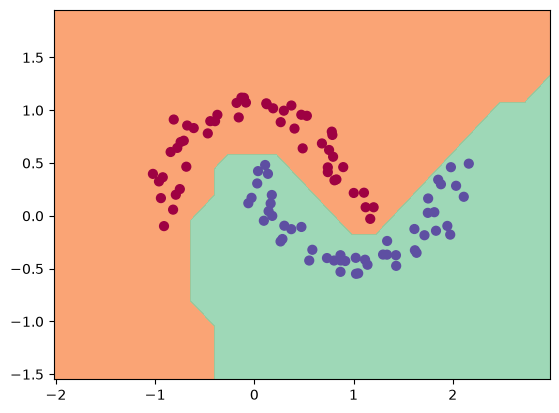

In [9]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
